In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
import plotly.express as px


import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Data_Train.csv.zip")

In [3]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [4]:
df.shape

(10683, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [7]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [9]:
df.dropna(axis=0, inplace=True)

In [10]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [11]:
df['Date_of_Journey'].dtype

dtype('O')

In [12]:
pd.to_datetime(df['Date_of_Journey'])

0       2019-03-24
1       2019-05-01
2       2019-06-09
3       2019-05-12
4       2019-03-01
           ...    
10678   2019-04-09
10679   2019-04-27
10680   2019-04-27
10681   2019-03-01
10682   2019-05-09
Name: Date_of_Journey, Length: 10682, dtype: datetime64[ns]

In [13]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])

In [14]:

df['journey_year'] = df['Date_of_Journey'].dt.year
df['journey_year'] = df['journey_year'].astype(int)

df['journey_year']

0        2019
1        2019
2        2019
3        2019
4        2019
         ... 
10678    2019
10679    2019
10680    2019
10681    2019
10682    2019
Name: journey_year, Length: 10682, dtype: int64

In [15]:
df['journey_month'] = df['Date_of_Journey'].dt.month
df['journey_month'] = df['journey_month'].astype(int)
df['journey_month']

0        3
1        5
2        6
3        5
4        3
        ..
10678    4
10679    4
10680    4
10681    3
10682    5
Name: journey_month, Length: 10682, dtype: int64

In [16]:
df['journey_day'] = df['Date_of_Journey'].dt.day
df['journey_day'] = df['Date_of_Journey'].dt.day
df['journey_day']


0        24
1         1
2         9
3        12
4         1
         ..
10678     9
10679    27
10680    27
10681     1
10682     9
Name: journey_day, Length: 10682, dtype: int32

In [17]:
df['journey_day'] = df['journey_day'].astype(int)
df['journey_day']

0        24
1         1
2         9
3        12
4         1
         ..
10678     9
10679    27
10680    27
10681     1
10682     9
Name: journey_day, Length: 10682, dtype: int64

In [18]:
df.drop("Date_of_Journey", axis=1, inplace=True)

In [19]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'journey_year',
       'journey_month', 'journey_day'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Source           10682 non-null  object
 2   Destination      10682 non-null  object
 3   Route            10682 non-null  object
 4   Dep_Time         10682 non-null  object
 5   Arrival_Time     10682 non-null  object
 6   Duration         10682 non-null  object
 7   Total_Stops      10682 non-null  object
 8   Additional_Info  10682 non-null  object
 9   Price            10682 non-null  int64 
 10  journey_year     10682 non-null  int64 
 11  journey_month    10682 non-null  int64 
 12  journey_day      10682 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 1.1+ MB


In [21]:
df['Arrival_Time'].unique()

array(['01:10 22 Mar', '13:15', '04:25 10 Jun', ..., '06:50 10 Mar',
       '00:05 19 Mar', '21:20 13 Mar'], shape=(1343,), dtype=object)

In [22]:
df['Arrival_Time'] = df['Arrival_Time'].apply(lambda x: x.split(" ")[0])
df['Arrival_Time']

0        01:10
1        13:15
2        04:25
3        23:30
4        21:35
         ...  
10678    22:25
10679    23:20
10680    11:20
10681    14:10
10682    19:15
Name: Arrival_Time, Length: 10682, dtype: object

In [23]:
df['Arrival_hour'] = df['Arrival_Time'].str.split(":").str[0]
df['Arrival_hour']

0        01
1        13
2        04
3        23
4        21
         ..
10678    22
10679    23
10680    11
10681    14
10682    19
Name: Arrival_hour, Length: 10682, dtype: object

In [24]:
df['Arrival_hour'] = df['Arrival_hour'].astype(int)
df['Arrival_hour'].dtype

dtype('int64')

In [25]:
df['Arrival_minute'] = df['Arrival_Time'].str.split(":").str[1]
df['Arrival_minute']

0        10
1        15
2        25
3        30
4        35
         ..
10678    25
10679    20
10680    20
10681    10
10682    15
Name: Arrival_minute, Length: 10682, dtype: object

In [26]:
df['Arrival_minute'] = df['Arrival_minute'].astype(int)
df['Arrival_minute'].dtype

dtype('int64')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Source           10682 non-null  object
 2   Destination      10682 non-null  object
 3   Route            10682 non-null  object
 4   Dep_Time         10682 non-null  object
 5   Arrival_Time     10682 non-null  object
 6   Duration         10682 non-null  object
 7   Total_Stops      10682 non-null  object
 8   Additional_Info  10682 non-null  object
 9   Price            10682 non-null  int64 
 10  journey_year     10682 non-null  int64 
 11  journey_month    10682 non-null  int64 
 12  journey_day      10682 non-null  int64 
 13  Arrival_hour     10682 non-null  int64 
 14  Arrival_minute   10682 non-null  int64 
dtypes: int64(6), object(9)
memory usage: 1.3+ MB


In [28]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'journey_year',
       'journey_month', 'journey_day', 'Arrival_hour', 'Arrival_minute'],
      dtype='object')

In [29]:
df.drop("Arrival_Time", axis=1, inplace=True)

In [30]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Dep_Time', 'Duration',
       'Total_Stops', 'Additional_Info', 'Price', 'journey_year',
       'journey_month', 'journey_day', 'Arrival_hour', 'Arrival_minute'],
      dtype='object')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Source           10682 non-null  object
 2   Destination      10682 non-null  object
 3   Route            10682 non-null  object
 4   Dep_Time         10682 non-null  object
 5   Duration         10682 non-null  object
 6   Total_Stops      10682 non-null  object
 7   Additional_Info  10682 non-null  object
 8   Price            10682 non-null  int64 
 9   journey_year     10682 non-null  int64 
 10  journey_month    10682 non-null  int64 
 11  journey_day      10682 non-null  int64 
 12  Arrival_hour     10682 non-null  int64 
 13  Arrival_minute   10682 non-null  int64 
dtypes: int64(6), object(8)
memory usage: 1.2+ MB


In [32]:
df['Dep_Time']

0        22:20
1        05:50
2        09:25
3        18:05
4        16:50
         ...  
10678    19:55
10679    20:45
10680    08:20
10681    11:30
10682    10:55
Name: Dep_Time, Length: 10682, dtype: object

In [33]:
df['Dep_hour'] = df['Dep_Time'].str.split(":").str[0]
df['Dep_hour']

0        22
1        05
2        09
3        18
4        16
         ..
10678    19
10679    20
10680    08
10681    11
10682    10
Name: Dep_hour, Length: 10682, dtype: object

In [34]:
df['Dep_hour'] = df['Dep_hour'].astype(int)
df['Dep_hour']

0        22
1         5
2         9
3        18
4        16
         ..
10678    19
10679    20
10680     8
10681    11
10682    10
Name: Dep_hour, Length: 10682, dtype: int64

In [35]:
df['Dep_minute'] = df['Dep_Time'].str[1]
df['Dep_minute']

0        2
1        5
2        9
3        8
4        6
        ..
10678    9
10679    0
10680    8
10681    1
10682    0
Name: Dep_minute, Length: 10682, dtype: object

In [36]:
df['Dep_minute'] = df['Dep_minute'].astype(int)
df['Dep_minute']

0        2
1        5
2        9
3        8
4        6
        ..
10678    9
10679    0
10680    8
10681    1
10682    0
Name: Dep_minute, Length: 10682, dtype: int64

In [37]:
df.drop("Dep_Time", axis=1, inplace=True)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Source           10682 non-null  object
 2   Destination      10682 non-null  object
 3   Route            10682 non-null  object
 4   Duration         10682 non-null  object
 5   Total_Stops      10682 non-null  object
 6   Additional_Info  10682 non-null  object
 7   Price            10682 non-null  int64 
 8   journey_year     10682 non-null  int64 
 9   journey_month    10682 non-null  int64 
 10  journey_day      10682 non-null  int64 
 11  Arrival_hour     10682 non-null  int64 
 12  Arrival_minute   10682 non-null  int64 
 13  Dep_hour         10682 non-null  int64 
 14  Dep_minute       10682 non-null  int64 
dtypes: int64(8), object(7)
memory usage: 1.3+ MB


In [39]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [40]:
from  sklearn.preprocessing import LabelEncoder

In [41]:
label = LabelEncoder()

In [42]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'journey_year', 'journey_month',
       'journey_day', 'Arrival_hour', 'Arrival_minute', 'Dep_hour',
       'Dep_minute'],
      dtype='object')

In [43]:
df['Total_Stops'] = label.fit_transform(df[['Total_Stops']])

In [44]:
df['Total_Stops'].value_counts()

Total_Stops
0    5625
4    3491
1    1520
2      45
3       1
Name: count, dtype: int64

#df['Total_Stops'].map({"non-stop'":0, "1 stop":1, "2 stops":2, "3 stops":3, "4 stops":4}) this is the another way to encode the Total_Stops means concverting object type to the int

In [45]:
df.drop("Route", axis=1, inplace=True)

In [46]:
df.columns


Index(['Airline', 'Source', 'Destination', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'journey_year', 'journey_month',
       'journey_day', 'Arrival_hour', 'Arrival_minute', 'Dep_hour',
       'Dep_minute'],
      dtype='object')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Source           10682 non-null  object
 2   Destination      10682 non-null  object
 3   Duration         10682 non-null  object
 4   Total_Stops      10682 non-null  int64 
 5   Additional_Info  10682 non-null  object
 6   Price            10682 non-null  int64 
 7   journey_year     10682 non-null  int64 
 8   journey_month    10682 non-null  int64 
 9   journey_day      10682 non-null  int64 
 10  Arrival_hour     10682 non-null  int64 
 11  Arrival_minute   10682 non-null  int64 
 12  Dep_hour         10682 non-null  int64 
 13  Dep_minute       10682 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 1.2+ MB


In [48]:
df['Duration']

0        2h 50m
1        7h 25m
2           19h
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680        3h
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: object

In [49]:
df['Duration_hour'] = df['Duration'].str.split(" ").str[0]

df['Duration_hour'] .unique()

array(['2h', '7h', '19h', '5h', '4h', '15h', '21h', '25h', '13h', '12h',
       '26h', '22h', '23h', '20h', '10h', '6h', '11h', '8h', '16h', '3h',
       '27h', '1h', '14h', '9h', '18h', '17h', '24h', '30h', '28h', '29h',
       '37h', '34h', '38h', '35h', '36h', '47h', '33h', '32h', '31h',
       '42h', '39h', '5m', '41h', '40h'], dtype=object)

In [50]:
df['Duration_hour'] = df['Duration_hour'].str.replace("h", "")
df['Duration_hour'] = df['Duration_hour'].str.replace("m", "")
df['Duration_hour'].unique()

array(['2', '7', '19', '5', '4', '15', '21', '25', '13', '12', '26', '22',
       '23', '20', '10', '6', '11', '8', '16', '3', '27', '1', '14', '9',
       '18', '17', '24', '30', '28', '29', '37', '34', '38', '35', '36',
       '47', '33', '32', '31', '42', '39', '41', '40'], dtype=object)

In [51]:
df['Duration_hour'] = df['Duration_hour'].astype(int)

In [52]:
df['Duration_minute'] = df['Duration'].str.split(" ").str[1]

In [53]:
df['Duration_minute'] = df['Duration_minute'].str.replace("m", "")

In [54]:
df['Duration_minute'].unique()

array(['50', '25', nan, '45', '30', '5', '15', '35', '10', '20', '55',
       '40'], dtype=object)

In [55]:
df = df.dropna(subset = ['Duration'
'_minute'])

In [56]:
df['Duration_minute'].unique()

array(['50', '25', '45', '30', '5', '15', '35', '10', '20', '55', '40'],
      dtype=object)

In [57]:
df['Duration_minute'] = df['Duration_minute'].astype(int)

In [58]:
df.drop("Duration", axis=1, inplace=True)

In [59]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info',
       'Price', 'journey_year', 'journey_month', 'journey_day', 'Arrival_hour',
       'Arrival_minute', 'Dep_hour', 'Dep_minute', 'Duration_hour',
       'Duration_minute'],
      dtype='object')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9650 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          9650 non-null   object
 1   Source           9650 non-null   object
 2   Destination      9650 non-null   object
 3   Total_Stops      9650 non-null   int64 
 4   Additional_Info  9650 non-null   object
 5   Price            9650 non-null   int64 
 6   journey_year     9650 non-null   int64 
 7   journey_month    9650 non-null   int64 
 8   journey_day      9650 non-null   int64 
 9   Arrival_hour     9650 non-null   int64 
 10  Arrival_minute   9650 non-null   int64 
 11  Dep_hour         9650 non-null   int64 
 12  Dep_minute       9650 non-null   int64 
 13  Duration_hour    9650 non-null   int64 
 14  Duration_minute  9650 non-null   int64 
dtypes: int64(11), object(4)
memory usage: 1.2+ MB


In [61]:
df['Additional_Info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [62]:
categorical = df[["Airline", "Source", "Destination", "Additional_Info"]]
categorical

,Airline,Source,Destination,Additional_Info
0,IndiGo,Banglore,New Delhi,No info
1,Air India,Kolkata,Banglore,No info
3,IndiGo,Kolkata,Banglore,No info
4,IndiGo,Banglore,New Delhi,No info
5,SpiceJet,Kolkata,Banglore,No info
...,...,...,...,...
10677,SpiceJet,Banglore,Delhi,No check-in baggage included
10678,Air Asia,Kolkata,Banglore,No info
10679,Air India,Kolkata,Banglore,No info
10681,Vistara,Banglore,New Delhi,No info


In [63]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

In [64]:
encoded_data = encoder.fit_transform(df[["Airline", "Source", "Destination", "Additional_Info"]]).toarray()



In [65]:
encoder.get_feature_names_out()

array(['Airline_Air Asia', 'Airline_Air India', 'Airline_GoAir',
       'Airline_IndiGo', 'Airline_Jet Airways',
       'Airline_Jet Airways Business', 'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara',
       'Airline_Vistara Premium economy', 'Source_Banglore',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai', 'Destination_Banglore', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi',
       'Additional_Info_1 Long layover',
       'Additional_Info_1 Short layover',
       'Additional_Info_2 Long layover', 'Additional_Info_Business class',
       'Additional_Info_Change airports',
       'Additional_Info_In-flight meal not included',
       'Additional_Info_No Info',
       'Additional_Info_No check-in baggage included',
       'Additional_Info_No info', 'Additional_Info_Red-eye fli

In [66]:
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out())

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9650 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          9650 non-null   object
 1   Source           9650 non-null   object
 2   Destination      9650 non-null   object
 3   Total_Stops      9650 non-null   int64 
 4   Additional_Info  9650 non-null   object
 5   Price            9650 non-null   int64 
 6   journey_year     9650 non-null   int64 
 7   journey_month    9650 non-null   int64 
 8   journey_day      9650 non-null   int64 
 9   Arrival_hour     9650 non-null   int64 
 10  Arrival_minute   9650 non-null   int64 
 11  Dep_hour         9650 non-null   int64 
 12  Dep_minute       9650 non-null   int64 
 13  Duration_hour    9650 non-null   int64 
 14  Duration_minute  9650 non-null   int64 
dtypes: int64(11), object(4)
memory usage: 1.2+ MB


In [68]:
df.drop(["Airline", "Source", "Destination", "Additional_Info"], axis=1, inplace=True)

In [69]:
df

,Total_Stops,Price,journey_year,journey_month,journey_day,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Duration_hour,Duration_minute
0,4,3897,2019,3,24,1,10,22,2,2,50
1,1,7662,2019,5,1,13,15,5,5,7,25
3,0,6218,2019,5,12,23,30,18,8,5,25
4,0,13302,2019,3,1,21,35,16,6,4,45
5,4,3873,2019,6,24,11,25,9,9,2,25
...,...,...,...,...,...,...,...,...,...,...,...
10677,4,3257,2019,5,21,8,35,5,5,2,40
10678,4,4107,2019,4,9,22,25,19,9,2,30
10679,4,4145,2019,4,27,23,20,20,0,2,35
10681,4,12648,2019,3,1,14,10,11,1,2,40


In [70]:
df = pd.concat([df, encoded_df], axis=1)

In [71]:
df

,Total_Stops,Price,journey_year,journey_month,journey_day,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Duration_hour,...,Additional_Info_1 Long layover,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,4.0,3897.0,2019.0,3.0,24.0,1.0,10.0,22.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,7662.0,2019.0,5.0,1.0,13.0,15.0,5.0,5.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,6218.0,2019.0,5.0,12.0,23.0,30.0,18.0,8.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,13302.0,2019.0,3.0,1.0,21.0,35.0,16.0,6.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,4.0,3873.0,2019.0,6.0,24.0,11.0,25.0,9.0,9.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9623,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10591 entries, 0 to 9649
Data columns (total 44 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Total_Stops                                   9650 non-null   float64
 1   Price                                         9650 non-null   float64
 2   journey_year                                  9650 non-null   float64
 3   journey_month                                 9650 non-null   float64
 4   journey_day                                   9650 non-null   float64
 5   Arrival_hour                                  9650 non-null   float64
 6   Arrival_minute                                9650 non-null   float64
 7   Dep_hour                                      9650 non-null   float64
 8   Dep_minute                                    9650 non-null   float64
 9   Duration_hour                                 9650 non-null   float

In [73]:
#Univeriate Analysis
#Multivariate Analysis
#Bivariate ANalysis
#target = prince
#do the train_test_split
#Scaling

In [74]:
df.columns

Index(['Total_Stops', 'Price', 'journey_year', 'journey_month', 'journey_day',
       'Arrival_hour', 'Arrival_minute', 'Dep_hour', 'Dep_minute',
       'Duration_hour', 'Duration_minute', 'Airline_Air Asia',
       'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Banglore', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai', 'Destination_Banglore', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata',
       'Destination_New Delhi', 'Additional_Info_1 Long layover',
       'Additional_Info_1 Short layover', 'Additional_Info_2 Long layover',
       'Additional_Info_Business class', 'Additional_Info_Change airports',
       'Additional_Info_In-flight mea

In [77]:
df['Total_Stops'].value_counts()

Total_Stops
0.0    5002
4.0    3230
1.0    1386
2.0      31
3.0       1
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

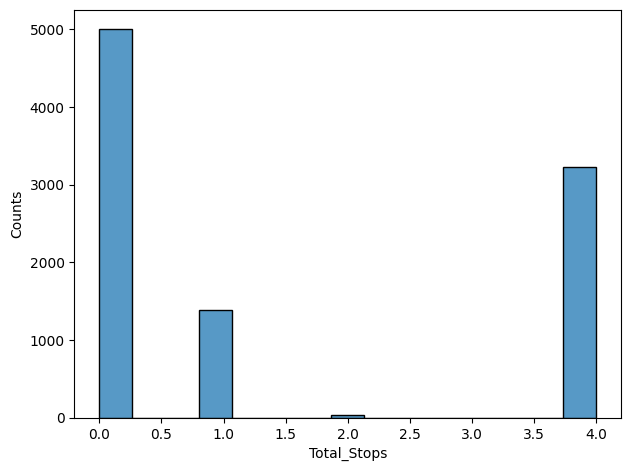

In [ ]:
sns.histplot(x='Total_Stops', data=df, palette='viridis')
sns.set_context('paper', )
plt.xlabel("Total_Stops")
plt.ylabel("Counts")
plt.tight_layout()
plt.show

In [80]:
df.columns

Index(['Total_Stops', 'Price', 'journey_year', 'journey_month', 'journey_day',
       'Arrival_hour', 'Arrival_minute', 'Dep_hour', 'Dep_minute',
       'Duration_hour', 'Duration_minute', 'Airline_Air Asia',
       'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Banglore', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai', 'Destination_Banglore', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata',
       'Destination_New Delhi', 'Additional_Info_1 Long layover',
       'Additional_Info_1 Short layover', 'Additional_Info_2 Long layover',
       'Additional_Info_Business class', 'Additional_Info_Change airports',
       'Additional_Info_In-flight mea

<Axes: xlabel='Price', ylabel='count'>

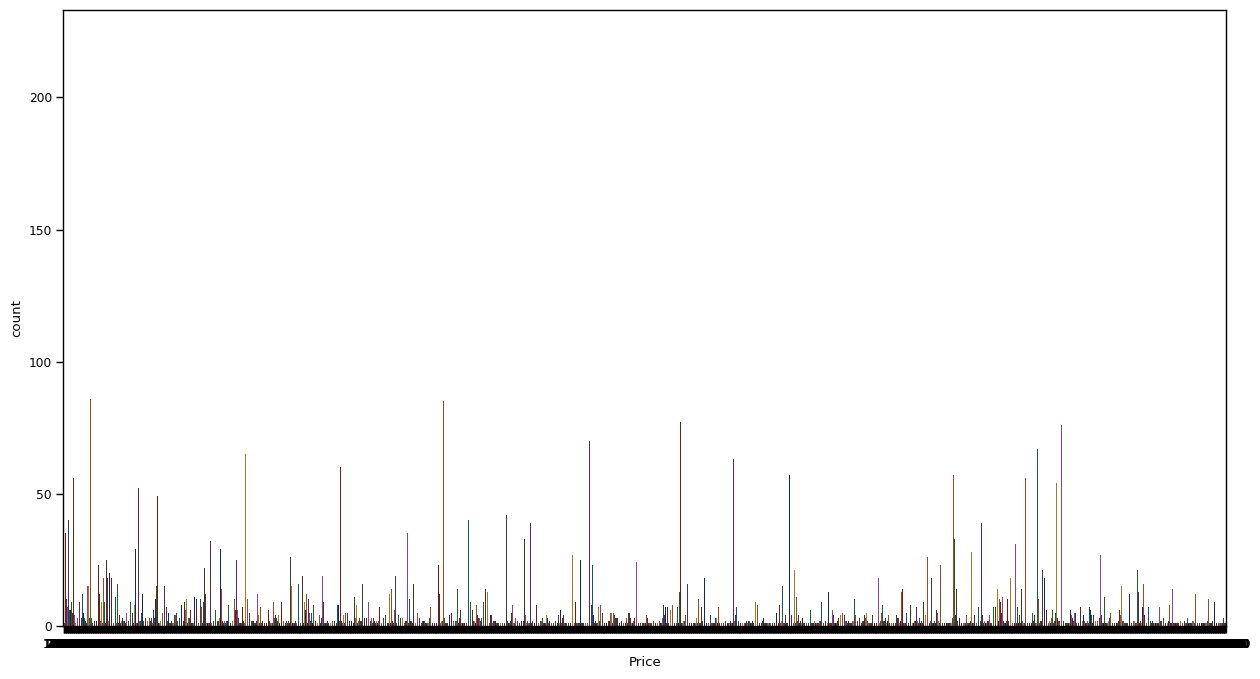

In [92]:
plt.figure(figsize=(15, 8))
sns.countplot(x="Price",   data = df, palette= 'dark')